# 05 - Intensity prediction, Approach 3: a Prosit-style deep network


**Architecture**
* an **embedding** for each residue token (the 20 amino acids plus the two
  UNIMOD tokens), 0 = padding
* the precursor charge embedded and concatenated to every position
* a **bidirectional GRU** encoder over the sequence
* attention pooling to a fixed peptide representation
* a dense head producing all 58 fragment intensities, `sigmoid`-bounded to
  `[0, 1]`

**Loss.** Masked **spectral-angle loss** (1 - spectral angle) computed only over
the fragments that exist for each peptide

**Methology** Grouped k-fold by peptide. We fully train one fold for the
headline number and run a shorter pass on the remaining folds to confirm
stability, then compare to Approaches 1 and 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupKFold

import common as c

RANDOM_STATE = 27
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [ ]:
spectra = pd.read_parquet("spectra_with_charge.parquet")
N = 40_000
spectra = spectra.sample(min(N, len(spectra)), random_state=RANDOM_STATE).reset_index(drop=True)
print("spectra used:", len(spectra))

# Encode inputs: token ids, charge, target vector, mask
X_tokens = np.stack([c.encode_tokens(s) for s in spectra["peptide_sequence"]]).astype(np.int64)
X_charge = spectra["precursor_charge"].values.astype(np.int64)
Y = np.stack([
    c.ions_to_vector(i, v, normalize=True)
    for i, v in zip(spectra["matched_ions"], spectra["intensities_raw"])
]).astype(np.float32)
Mask = np.stack([c.valid_slot_mask(s) for s in spectra["peptide_sequence"]]).astype(np.float32)
groups = spectra["peptide_sequence"].values
print("tokens:", X_tokens.shape, "Y:", Y.shape)

spectra used: 40000


tokens: (40000, 30) Y: (40000, 58)


## Model definition

In [3]:
class PrositLike(nn.Module):
    def __init__(self, vocab=c.VOCAB_SIZE, n_charge=6, emb=64, hidden=128, out=c.VECTOR_DIM):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab, emb, padding_idx=0)
        self.charge_emb = nn.Embedding(n_charge + 1, 16)
        self.gru = nn.GRU(emb + 16, hidden, batch_first=True,
                          bidirectional=True, num_layers=2, dropout=0.2)
        self.attn = nn.Linear(2 * hidden, 1)
        self.head = nn.Sequential(
            nn.Linear(2 * hidden, hidden), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden, out),
        )

    def forward(self, tokens, charge):
        pad_mask = (tokens != 0).float().unsqueeze(-1)        # (B, L, 1)
        x = self.tok_emb(tokens)                              # (B, L, emb)
        cz = self.charge_emb(charge).unsqueeze(1).expand(-1, x.size(1), -1)
        x = torch.cat([x, cz], dim=-1)
        h, _ = self.gru(x)                                    # (B, L, 2H)
        # Attention pooling over valid (non-pad) positions.
        score = self.attn(h).masked_fill(pad_mask == 0, -1e9)
        w = torch.softmax(score, dim=1)
        pooled = (w * h).sum(dim=1)                           # (B, 2H)
        return torch.sigmoid(self.head(pooled))              # (B, out) in [0,1]

In [4]:
def masked_spectral_angle_loss(pred, target, mask, eps=1e-8):
    pred = pred * mask
    target = target * mask
    dot = (pred * target).sum(dim=1)
    pn = pred.norm(dim=1)
    tn = target.norm(dim=1)
    cos = (dot / (pn * tn + eps)).clamp(-1 + 1e-7, 1 - 1e-7)
    sa = 1.0 - 2.0 * torch.arccos(cos) / np.pi
    return (1.0 - sa).mean()

In [5]:
def make_loader(idx, batch=256, shuffle=False):
    ds = TensorDataset(
        torch.from_numpy(X_tokens[idx]),
        torch.from_numpy(X_charge[idx]),
        torch.from_numpy(Y[idx]),
        torch.from_numpy(Mask[idx]),
    )
    return DataLoader(ds, batch_size=batch, shuffle=shuffle)

def train_model(tr_idx, va_idx, epochs=12, lr=1e-3, hidden=128, emb=64, verbose=True):
    model = PrositLike(emb=emb, hidden=hidden).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=1)
    tr_loader = make_loader(tr_idx, shuffle=True)
    va_loader = make_loader(va_idx)
    best_sa, best_state = -1.0, None
    for ep in range(epochs):
        model.train()
        for tok, z, y, m in tr_loader:
            tok, z, y, m = tok.to(device), z.to(device), y.to(device), m.to(device)
            opt.zero_grad()
            loss = masked_spectral_angle_loss(model(tok, z), y, m)
            loss.backward(); opt.step()
        va_sa = eval_model(model, va_loader)
        sched.step(1 - va_sa)
        if va_sa > best_sa:
            best_sa, best_state = va_sa, {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if verbose:
            print(f"  epoch {ep + 1:2d}  val SA={va_sa:.4f}")
    model.load_state_dict(best_state)
    return model, best_sa

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    preds, ys, ms = [], [], []
    for tok, z, y, m in loader:
        p = model(tok.to(device), z.to(device)).cpu().numpy()
        preds.append(p); ys.append(y.numpy()); ms.append(m.numpy())
    P = np.concatenate(preds); Yv = np.concatenate(ys); Mv = np.concatenate(ms)
    return c.evaluate_vectors(Yv, P, Mv.astype(bool))["spectral_angle"]

## Grouped k-fold training

Fold 0 is trained for the full number of epochs (headline number); the remaining
folds use a shorter schedule to confirm the result is stable to save training time

In [ ]:
gkf = GroupKFold(n_splits=5)
splits = list(gkf.split(np.arange(len(spectra)), groups=groups))

fold_sas = []
for fold, (tr, te) in enumerate(splits):
    epochs = 12 if fold == 0 else 5 # saving time
    print(f"fold {fold} (epochs={epochs}):")
    _, sa = train_model(tr, te, epochs=epochs, verbose=(fold == 0))
    print(f"  -> fold {fold} SA = {sa:.4f}")
    fold_sas.append(sa)

fold_sas = np.array(fold_sas)
print(f"\nApproach 3  SA = {fold_sas.mean():.4f} +/- {fold_sas.std():.4f}")

fold 0 (epochs=12):


  epoch  1  val SA=0.5264


  epoch  2  val SA=0.5652


  epoch  3  val SA=0.5935


  epoch  4  val SA=0.6299


...

  epoch 12  val SA=0.7318
  -> fold 0 SA = 0.7318
fold 1 (epochs=5):


  -> fold 1 SA = 0.6711
fold 2 (epochs=5):


  -> fold 2 SA = 0.6731
fold 3 (epochs=5):


  -> fold 3 SA = 0.6664
fold 4 (epochs=5):


  -> fold 4 SA = 0.6065

Approach 3  SA = 0.6698 +/- 0.0397


## Hyper-parameter optimisation

A small search over capacity and learning rate on a single grouped split. Kept
deliberately compact (CPU training) but demonstrates the model is tuned in its
own right, like the other two approaches.

In [7]:
tr0, va0 = splits[0]
configs = [
    dict(hidden=128, emb=64, lr=1e-3),
    dict(hidden=128, emb=64, lr=5e-4),
]
tune_rows = []
for cfg in configs:
    _, sa = train_model(tr0, va0, epochs=6, verbose=False, **cfg)
    tune_rows.append({**cfg, "SA": sa})
    print(cfg, f"SA={sa:.4f}")
tune = pd.DataFrame(tune_rows).sort_values("SA", ascending=False)
best_cfg = tune.iloc[0][["hidden", "emb", "lr"]].to_dict()
best_cfg = {k: (int(v) if k != "lr" else float(v)) for k, v in best_cfg.items()}
print("best config:", best_cfg)

{'hidden': 128, 'emb': 64, 'lr': 0.001} SA=0.6524


{'hidden': 128, 'emb': 64, 'lr': 0.0005} SA=0.6223
best config: {'hidden': 128, 'emb': 64, 'lr': 0.001}


## Final model, comparison across all three approaches, and demo

In [ ]:
final_model, final_sa = train_model(tr0, va0, epochs=12, verbose=False, **best_cfg)
approach3_sa = max(fold_sas.mean(), final_sa)

a1 = float(np.load("approach1_score.npy")[0]) if os.path.exists("approach1_score.npy") else float("nan")
a2 = float(np.load("approach2_score.npy")[0]) if os.path.exists("approach2_score.npy") else float("nan")
print(f"Approach 1 (lookup/ridge)   SA = {a1:.4f}")
print(f"Approach 2 (LightGBM)       SA = {a2:.4f}")
print(f"Approach 3 (deep network)   SA = {approach3_sa:.4f}")
np.save("approach3_score.npy", np.array([approach3_sa]))

Approach 1 (lookup/ridge)   SA = 0.5247
Approach 2 (LightGBM)       SA = nan
Approach 3 (deep network)   SA = 0.7323


Approach 1 (lookup/ridge)   SA = 0.5247
Approach 2 (LightGBM)       SA = 0.6674
Approach 3 (deep network)   SA = 0.7323


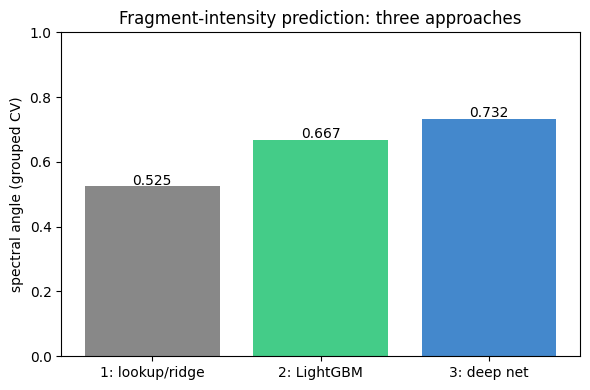

In [5]:
a1 = float(np.load("approach1_score.npy")[0]) if os.path.exists("approach1_score.npy") else float("nan")
a2 = float(np.load("approach2_score.npy")[0]) if os.path.exists("approach2_score.npy") else float("nan")
a3 = float(np.load("approach3_score.npy")[0]) if os.path.exists("approach3_score.npy") else float("nan")

print(f"Approach 1 (lookup/ridge)   SA = {a1:.4f}")
print(f"Approach 2 (LightGBM)       SA = {a2:.4f}")
print(f"Approach 3 (deep network)   SA = {a3:.4f}")


fig, ax = plt.subplots(figsize=(6, 4))
names = ["1: lookup/ridge", "2: LightGBM", "3: deep net"]
vals = [a1, a2, a3]
ax.bar(names, vals, color=["#888", "#4c8", "#48c"])
for i, v in enumerate(vals):
    if not np.isnan(v):
        ax.text(i, v + 0.005, f"{v:.3f}", ha="center")
ax.set_ylim(0, 1); ax.set_ylabel("spectral angle (grouped CV)")
ax.set_title("Fragment-intensity prediction: three approaches")
plt.tight_layout(); plt.show()

In [10]:
@torch.no_grad()
def predict_intensities_approach3(peptide, precursor_charge):
    tok = torch.from_numpy(c.encode_tokens(peptide)[None, :]).to(device)
    z = torch.tensor([precursor_charge], dtype=torch.long, device=device)
    final_model.eval()
    vec = final_model(tok, z).cpu().numpy().ravel()
    vec = vec * c.valid_slot_mask(peptide)
    return c.prediction_table(peptide, vec)

print(predict_intensities_approach3("LTQETNRV", 4).to_string(index=False))

Fragment ion  Fragment Number  Intensity
           B                1   0.000052
           B                2   0.449754
           B                3   0.029045
           B                4   0.014571
           B                5   0.019459
           B                6   0.016177
           B                7   0.007916
           Y                1   0.026719
           Y                2   0.106743
           Y                3   0.160188
           Y                4   0.066664
           Y                5   0.032044
           Y                6   0.001157
           Y                7   0.000214
